# SoftMax function

$\Large{ \sigma(z) = \frac{1}{1 + e ^ {-z}}}$

Where,

$\Large{z = w^Tx + b}$  (Just like linear regression output)

This gives us probability that the output is 1

Where,

$\Large{\hat{y} = \sigma (w^Tx + b)}$

This predicts 1 if $\hat{y} >= 0.5$ else 0

# Binary Cross Entropy(Loss Function)

We don't use MSE as loss function like in linear regression. Since, this is classification problem, we will use BCE.

$ \Large{\mathcal{L}(y, \hat{y}) = -[y \log(\hat{y}) + (1 - y) \log(1 - \hat{y})] }$

# Cost Function

$\Large{J(w, b) = \frac{1}{m} \sum_{i=1}^{m} \mathcal{L}(y^{(i)}, \hat{y}^{(i)})}$

This gets updated using gradient descent as:

$\Large{w := w -}$ $\Large{\alpha \frac{\partial{J}}{\partial{w}}}$

$\Large{b := b -}$ $\Large{ \alpha \frac{\partial{J}}{\partial{b}}} $

For converting to numeric and code based computation. The following is the theory behind it:

- Hypothesis is $h(x) = \Large{\frac{1}{1 + e^{-x}}}$
- $ z = \theta ^{T}x $ &emsp;Where, x is the feature vector and $\theta$ is the parameter vector

Similarly, cost function is given by:
$\Large{J(\theta) = -\frac{1}{m}\sum\limits_{i = 1}^{m} (y^{(i)} log(h(x^{(i)})) + (1 + y^{(i)})log(1 - h(x^{(i)})))}$

m being the total training samples

The gradient of the cost function is given as:
$\Large{\frac{\partial{J}}{\partial{\theta}} = \frac{1}{m}\sum\limits_{i = 1}^{m}(h(x^{(i)}) - y^{(i)}) x^{(i)}}$

In [64]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [65]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

Now we seperate setosa and non-setosa using binary classification

So, for this case, 1 is setosa and 0 is non-setosa

In [66]:
print(f"{X}\n{y}")

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

#### `np.where()` -> condition, set value, broadcast value

In [67]:
y = np.where(y==0, 1, 0) # Assuming in the dataset setosa is already set to 0

In [68]:
print(y)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [69]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# print(X_scaled)

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=96, test_size=0.2)

In [71]:
def sigmoid(z):
    return (1/(1 + np.exp(-z)))

In [72]:
def predict(X, theta):
    return sigmoid(np.dot(X,theta))

Again cost is given as:

$\Large{J(\theta) = -\frac{1}{m}\sum\limits_{i = 1}^{m} (y^{(i)} log(h(x^{(i)})) + (1 - y^{(i)})log(1 - h(x^{(i)})))}$

In [73]:
def compute_cost(X,y, theta):
    m = len(y)
    predictions = predict(X, theta)
    cost = -(1/m) * np.sum(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
    return cost

In [74]:
def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = []

    for _ in range(iterations):
        predictions = predict(X, theta)
        gradient = (1/m) * np.dot(X.T, (predictions - y))
        theta = theta - (learning_rate * gradient)
        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

Now we add the bias term $\theta_0$ to the feature matrix because the prediction is: $h_\theta(x) = \sigma(\theta_0 + \theta_1x_1 + \ldots + \theta_nx_n)$

In [75]:
X_train_bias = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_bias = np.c_[np.ones((X_test.shape[0], 1)), X_test]
# This is just concatenating the theta 0 to the feature vectors along the column axis

In [76]:
theta_initial = np.zeros(X_train_bias.shape[1]) # Standard practice to set initial value to zeros, watch out for multiple local minima

# Training

In [77]:
learning_rate = 0.01
iterations = 1000
theta_optimal, cost_history = gradient_descent(X_train_bias, y_train, theta_initial, learning_rate, iterations)

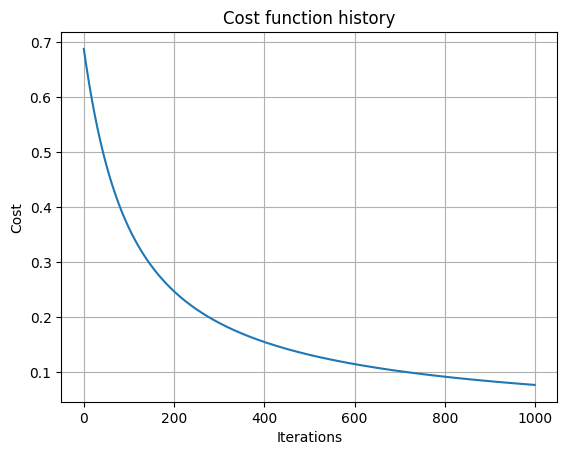

In [78]:
import matplotlib.pyplot as plt
plt.plot(range(iterations), cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost function history')
plt.grid(True)
# plt.xticks(np.arange(0,800, 100))
# plt.yticks(np.arange(0,0.8, 0.05))
plt.show()

# Don't touch the below cell with a ten foot pole since I haven't gotten into it

In [79]:
# Step 6: Evaluate the model
def accuracy(X, y, theta):
    predictions = predict(X, theta)
    predicted_labels = (predictions >= 0.5).astype(int)
    return np.mean(predicted_labels == y)

train_accuracy = accuracy(X_train_bias, y_train, theta_optimal)
test_accuracy = accuracy(X_test_bias, y_test, theta_optimal)

print(f'Training accuracy: {train_accuracy * 100:.2f}%')
print(f'Test accuracy: {test_accuracy * 100:.2f}%')


Training accuracy: 100.00%
Test accuracy: 100.00%


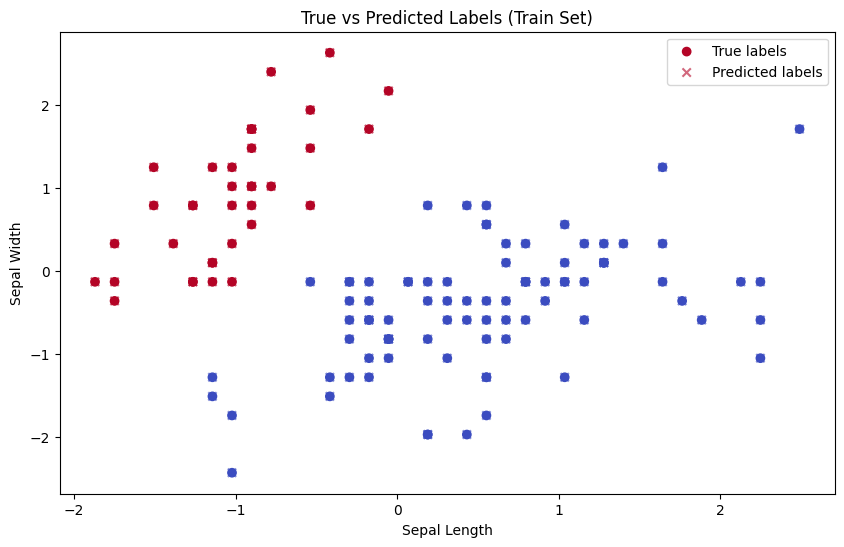

In [80]:
import matplotlib.pyplot as plt

# Step 1: Get predictions
predictions_train = predict(X_train_bias, theta_optimal)
predictions_train_label = (predictions_train >= 0.5).astype(int)  # Convert to 0 or 1

# Step 2: Plot true vs predicted labels
plt.figure(figsize=(10, 6))

# True labels
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', marker='o', label='True labels')

# Predicted labels
plt.scatter(X_train[:, 0], X_train[:, 1], c=predictions_train_label, cmap='coolwarm', marker='x', alpha=0.6, label='Predicted labels')

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('True vs Predicted Labels (Train Set)')
plt.legend()
plt.show()
